In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")

In [3]:
df = pd.read_csv("../data/german_credit_data.csv")
df.head()

,Unnamed: 0,Age,Sex,Job,Housing,Saving accounts,Checking account,Credit amount,Duration,Purpose
0,0,67,male,2,own,NaN,little,1169,6,radio/TV
1,1,22,female,2,own,little,moderate,5951,48,radio/TV
2,2,49,male,1,own,little,NaN,2096,12,education
3,3,45,male,2,free,little,little,7882,42,furniture/equipment
4,4,53,male,2,free,little,little,4870,24,car


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 10 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   Unnamed: 0        1000 non-null   int64 
 1   Age               1000 non-null   int64 
 2   Sex               1000 non-null   object
 3   Job               1000 non-null   int64 
 4   Housing           1000 non-null   object
 5   Saving accounts   817 non-null    object
 6   Checking account  606 non-null    object
 7   Credit amount     1000 non-null   int64 
 8   Duration          1000 non-null   int64 
 9   Purpose           1000 non-null   object
dtypes: int64(5), object(5)
memory usage: 78.3+ KB


In [5]:
df.describe()

,Unnamed: 0,Age,Job,Credit amount,Duration
count,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000
mean,499.500000,35.546000,1.904000,3271.258000,20.903000
std,288.819436,11.375469,0.653614,2822.736876,12.058814
min,0.000000,19.000000,0.000000,250.000000,4.000000
25%,249.750000,27.000000,2.000000,1365.500000,12.000000
50%,499.500000,33.000000,2.000000,2319.500000,18.000000
75%,749.250000,42.000000,2.000000,3972.250000,24.000000
max,999.000000,75.000000,3.000000,18424.000000,72.000000


In [6]:
df = df.drop(columns=['Unnamed: 0'])

In [7]:
df['Saving accounts'] = df['Saving accounts'].fillna('no_account')
df['Checking account'] = df['Checking account'].fillna('no_account')

In [8]:
df.isnull().sum()

Age                 0
Sex                 0
Job                 0
Housing             0
Saving accounts     0
Checking account    0
Credit amount       0
Duration            0
Purpose             0
dtype: int64

In [9]:
df.dtypes

Age                  int64
Sex                 object
Job                  int64
Housing             object
Saving accounts     object
Checking account    object
Credit amount        int64
Duration             int64
Purpose             object
dtype: object

In [10]:
df.duplicated().sum()

np.int64(0)

In [11]:
df.head()

,Age,Sex,Job,Housing,Saving accounts,Checking account,Credit amount,Duration,Purpose
0,67,male,2,own,no_account,little,1169,6,radio/TV
1,22,female,2,own,little,moderate,5951,48,radio/TV
2,49,male,1,own,little,no_account,2096,12,education
3,45,male,2,free,little,little,7882,42,furniture/equipment
4,53,male,2,free,little,little,4870,24,car


In [12]:
df.columns = df.columns.str.replace(' ', '_')

In [17]:
df.head(20)

,Age,Sex,Job,Housing,Saving_accounts,Checking_account,Credit_amount,Duration,Purpose
0,67,male,2,own,no_account,little,1169,6,radio/TV
1,22,female,2,own,little,moderate,5951,48,radio/TV
2,49,male,1,own,little,no_account,2096,12,education
3,45,male,2,free,little,little,7882,42,furniture/equipment
4,53,male,2,free,little,little,4870,24,car
5,35,male,1,free,no_account,no_account,9055,36,education
6,53,male,2,own,quite rich,no_account,2835,24,furniture/equipment
7,35,male,3,rent,little,moderate,6948,36,car
8,61,male,1,own,rich,no_account,3059,12,radio/TV
9,28,male,3,own,little,moderate,5234,30,car


In [15]:
df.to_csv("../data/processed/cleaned_data.csv", index=False)

In [24]:
def compute_risk(row):
    score = 0

    # 1. Age
    if row['Age'] < 25:
        score += 3
    elif row['Age'] < 35:
        score += 2
    elif row['Age'] > 60:
        score += 1

    # 2. Job stability (0=unskilled non-resident, 1=unskilled, 2=skilled, 3=highly skilled)
    job_risk = {0: 4, 1: 3, 2: 1, 3: 0}
    score += job_risk.get(row['Job'], 2)

    # 3. Housing
    housing_risk = {'own': 0, 'free': 2, 'rent': 3}
    score += housing_risk.get(row['Housing'], 2)

    # 4. Saving accounts
    saving_risk = {'rich': 0, 'quite rich': 1, 'moderate': 2, 'little': 3, 'no_account': 4}
    score += saving_risk.get(row['Saving_accounts'], 3)

    # 5. Checking account
    checking_risk = {'moderate': 1, 'little': 2, 'no_account': 3}
    score += checking_risk.get(row['Checking_account'], 0)

    # 6. Monthly burden (credit amount / duration)
    monthly_burden = row['Credit_amount'] / row['Duration']
    if monthly_burden > 400:
        score += 3
    elif monthly_burden > 250:
        score += 2
    elif monthly_burden > 150:
        score += 1

    # 7. Loan duration
    if row['Duration'] > 36:
        score += 3
    elif row['Duration'] > 24:
        score += 2
    elif row['Duration'] > 12:
        score += 1

    # 8. Purpose
    purpose_risk = {
        'car': 1, 'radio/TV': 1,
        'furniture/equipment': 2, 'education': 2,
        'business': 3, 'vacation/others': 3
    }
    score += purpose_risk.get(row['Purpose'], 2)

    # Map score to risk label
    if score <= 6:
        return 'Low'
    elif score <= 11:
        return 'Medium'
    elif score <= 15:
        return 'High'
    else:
        return 'Very High'


# Apply to your dataframe
df['Risk'] = df.apply(compute_risk, axis=1)

In [25]:
df.head()

,Age,Sex,Job,Housing,Saving_accounts,Checking_account,Credit_amount,Duration,Purpose,Risk
0,67,male,2,own,no_account,little,1169,6,radio/TV,Medium
1,22,female,2,own,little,moderate,5951,48,radio/TV,High
2,49,male,1,own,little,no_account,2096,12,education,High
3,45,male,2,free,little,little,7882,42,furniture/equipment,High
4,53,male,2,free,little,little,4870,24,car,Medium


In [26]:
df['Risk'].value_counts()

Risk
Medium       529
High         370
Very High     65
Low           36
Name: count, dtype: int64

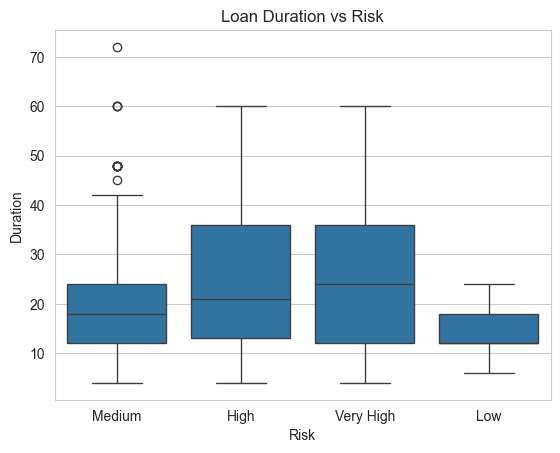

In [27]:
sns.boxplot(x='Risk', y='Duration', data=df)
plt.title("Loan Duration vs Risk")
plt.show()

Customers with higher risk levels (High / Very High) tend to have longer loan durations compared to low-risk customers.
This suggests that long-term loans are associated with higher default risk, likely due to increased uncertainty over time.

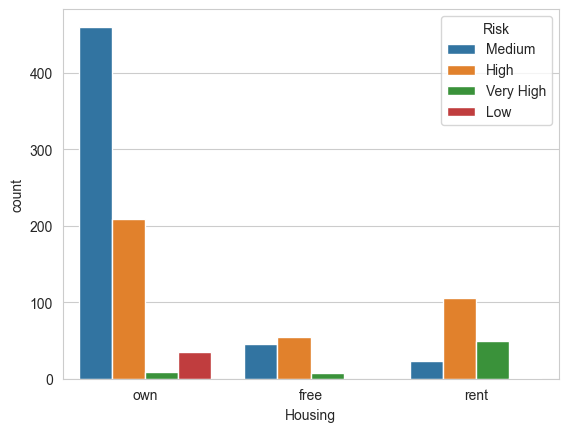

In [28]:
sns.countplot(x='Housing', hue='Risk', data=df)
plt.show()

Customers who own their homes represent the largest group and generally show lower risk levels, while customers who rent have a noticeably higher proportion of high and very high risk.

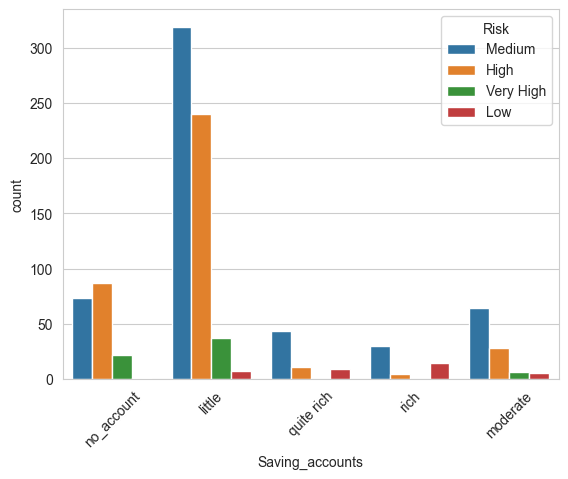

In [29]:
sns.countplot(x='Saving_accounts', hue='Risk', data=df)
plt.xticks(rotation=45)
plt.show()

Customers with little or no savings have a significantly higher proportion of high and very high risk, whereas customers with rich or quite rich savings tend to fall into lower risk categories.

Customers with low savings, rented housing, and long loan durations represent the highest risk group, indicating that financial instability and long-term obligations significantly increase default probability.